# Q3 Predictive Analytics: From Intake Profiles to Expected Service Demand

This notebook uses historical client intake features to predict trajectory cluster membership
and then estimates session capacity demand for the current waitlist.

**Structure:**
- **(a)** EDA: intake features across trajectory clusters from Q2
- **(b)** Two classifiers (logistic regression + random forest) with accuracy and confusion matrices
- **(c)** Waitlist predictions and total capacity estimate under the differentiated policy

In [23]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

# ── Q2 constants (must match Q2.ipynb exactly) ─────────────────────────────
TMAX     = 12
ALPHA    = 0.90
K_FINAL  = 3
SESSIONS = np.arange(1, TMAX + 1)
CLUSTER_COLORS = ["#4C72B0", "#DD8452", "#55A868"]
CLUSTER_NAMES  = ["Low-gain", "Mid-gain", "High-gain"]
CLUSTER_LABELS = [f"Cluster {k}: {CLUSTER_NAMES[k]}" for k in range(K_FINAL)]

SCORED_PATH   = Path("data/scored_notes.csv")
FEATURES_PATH = Path("data/client_features.csv")
WAITLIST_PATH = Path("data/waitlist.csv")

print("Imports OK")

Imports OK


## Reproduce Q2 Clustering Pipeline

Re-run the trajectory construction and K-means clustering (K=3) on the historical clients,
using raw cumulative trajectories sorted by mean final cumulative, to obtain cluster
assignments and cluster-level Q* values consistent with Q2.

In [24]:
# ── Build trajectories from scored_notes.csv ───────────────────────────────
scored = pd.read_csv(SCORED_PATH)
trajectories = {}
for cid, grp in scored.groupby("client_id"):
    scores = grp.sort_values("session")["score"].values
    trajectories[cid] = np.concatenate([[0], np.cumsum(scores)])

client_ids  = sorted(trajectories.keys())
traj_matrix = np.array([trajectories[cid] for cid in client_ids])

# ── Compute t* ─────────────────────────────────────────────────────────────
def compute_tstar(traj, alpha=ALPHA, tmax=TMAX):
    total = traj[-1]
    if total == 0:
        return tmax
    threshold = alpha * total
    for idx, val in enumerate(traj):
        if val >= threshold:
            return idx + 1
    return tmax

tstars_all = np.array([compute_tstar(t) for t in traj_matrix])

# ── K-means (K=3) with clusters sorted by mean final cumulative ────────────
np.random.seed(42)
km = KMeans(n_clusters=K_FINAL, n_init=20, random_state=42)
raw_labels  = km.fit_predict(traj_matrix)
order       = np.argsort([traj_matrix[raw_labels == c, -1].mean() for c in range(K_FINAL)])
label_map   = {old: new for new, old in enumerate(order)}
cluster_labels = np.array([label_map[l] for l in raw_labels])

# ── Newsvendor Q* per cluster ──────────────────────────────────────────────
def savings_curve(t_stars, tmax=TMAX):
    t = np.array(t_stars)
    return np.array([np.mean(t <= q) * (tmax - q) for q in SESSIONS])

cluster_policy = {}
for c in range(K_FINAL):
    mask = cluster_labels == c
    ts   = tstars_all[mask]
    sc   = savings_curve(ts)
    idx  = int(np.argmax(sc))
    cluster_policy[c] = {
        "n":          int(mask.sum()),
        "qstar":      int(SESSIONS[idx]),
        "esaved":     float(sc[idx]),
        "edelivered": TMAX - float(sc[idx]),
    }

print("Cluster policies (reproduced from Q2):")
policy_df = pd.DataFrame(cluster_policy).T
policy_df.index = CLUSTER_LABELS
policy_df[["n", "qstar", "esaved", "edelivered"]].rename(
    columns={"n": "Size", "qstar": "Q*",
             "esaved": "E[saved/child]", "edelivered": "E[delivered/child]"})

Cluster policies (reproduced from Q2):


,Size,Q*,E[saved/child],E[delivered/child]
Cluster 0: Low-gain,17.0,5.0,4.117647,7.882353
Cluster 1: Mid-gain,38.0,8.0,3.157895,8.842105
Cluster 2: High-gain,25.0,9.0,2.640000,9.360000


In [ ]:
# ── Merge cluster labels with intake features ──────────────────────────────
# Historical clients = unlabeled split (scored by Claude Opus 4.6 in Q1b, clustered in Q2).
# The 40 labeled clients (Patel's hand-scores) are only for Q1(a) validation.
cluster_ser = pd.Series(cluster_labels, index=client_ids, name="cluster")

features_df = pd.read_csv(FEATURES_PATH)
hist_df = features_df[features_df["dataset_split"] == "unlabeled"].copy()
hist_df = hist_df.set_index("client_id")
hist_df["cluster"] = cluster_ser
hist_df = hist_df.dropna(subset=["cluster"])   # drop any without a scored trajectory
hist_df["cluster"] = hist_df["cluster"].astype(int)
hist_df = hist_df.reset_index()

print(f"Historical clients with cluster assignments: {len(hist_df)}")
print(f"Cluster distribution:")
print(hist_df["cluster"].value_counts().sort_index().to_string())
hist_df.head()

## Part (a) — Exploring Intake Features by Trajectory Type

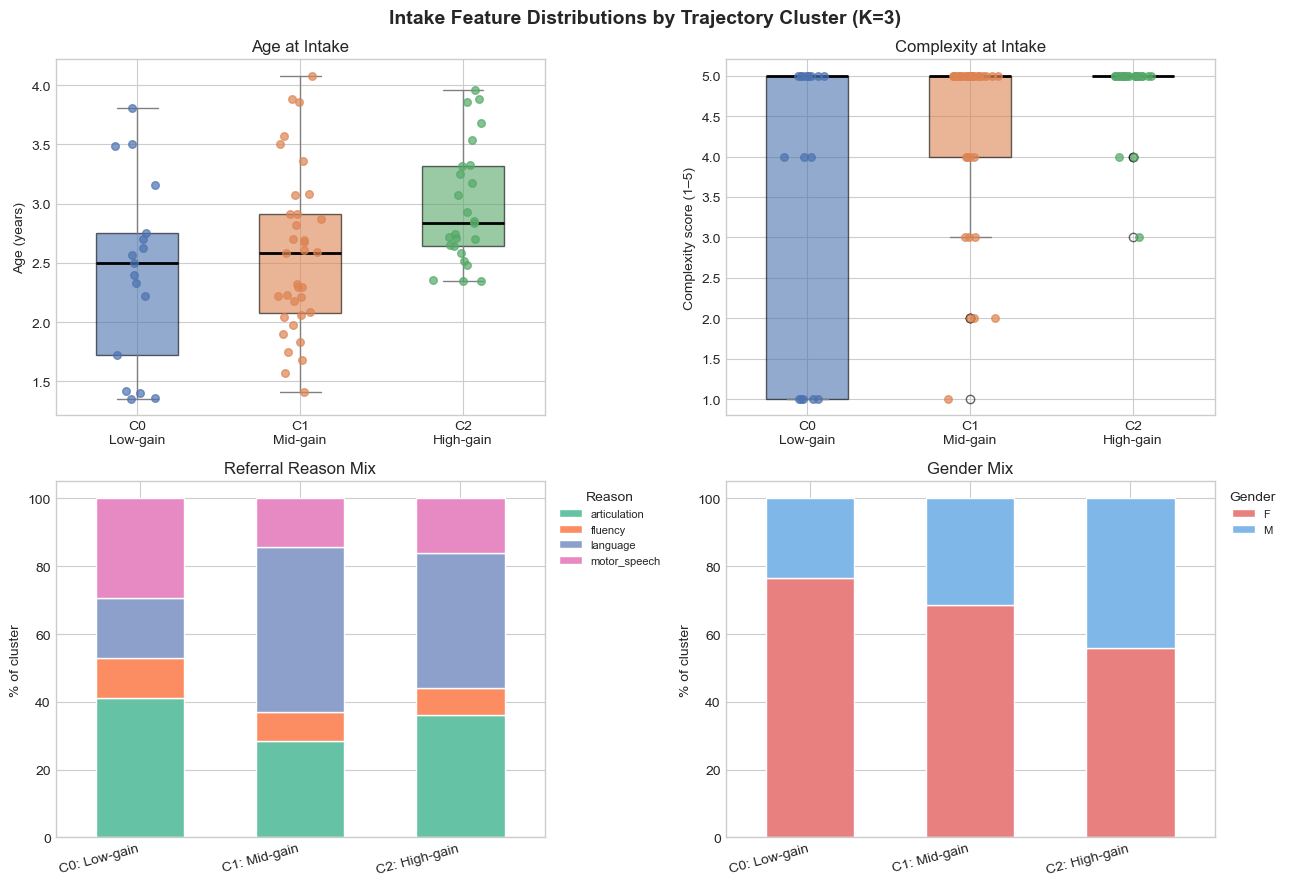

,n,age_mean,age_sd,complexity_mean,complexity_sd
Cluster 0: Low-gain,17,2.43,0.79,3.65,1.80
Cluster 1: Mid-gain,35,2.57,0.68,4.34,1.14
Cluster 2: High-gain,25,2.98,0.50,4.84,0.47


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Intake Feature Distributions by Trajectory Cluster (K={K_FINAL})",
             fontsize=14, fontweight="bold")

# 1. Age by cluster
ax = axes[0, 0]
for k in range(K_FINAL):
    sub = hist_df[hist_df["cluster"] == k]["age_years"]
    pos = k + 1
    ax.boxplot(sub, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=CLUSTER_COLORS[k], alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(color="grey"), capprops=dict(color="grey"),
               flierprops=dict(marker="o", color=CLUSTER_COLORS[k], alpha=0.6))
    ax.scatter(np.random.normal(pos, 0.07, size=len(sub)), sub,
               color=CLUSTER_COLORS[k], alpha=0.7, s=30, zorder=3)
ax.set_xticks(list(range(1, K_FINAL + 1)))
ax.set_xticklabels([f"C{k}\n{CLUSTER_NAMES[k]}" for k in range(K_FINAL)])
ax.set_ylabel("Age (years)"); ax.set_title("Age at Intake")

# 2. Complexity by cluster
ax = axes[0, 1]
for k in range(K_FINAL):
    sub = hist_df[hist_df["cluster"] == k]["complexity_score"]
    pos = k + 1
    ax.boxplot(sub, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=CLUSTER_COLORS[k], alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(color="grey"), capprops=dict(color="grey"),
               flierprops=dict(marker="o", color=CLUSTER_COLORS[k], alpha=0.6))
    ax.scatter(np.random.normal(pos, 0.07, size=len(sub)), sub,
               color=CLUSTER_COLORS[k], alpha=0.7, s=30, zorder=3)
ax.set_xticks(list(range(1, K_FINAL + 1)))
ax.set_xticklabels([f"C{k}\n{CLUSTER_NAMES[k]}" for k in range(K_FINAL)])
ax.set_ylabel("Complexity score (1–5)"); ax.set_title("Complexity at Intake")

# 3. Referral reason
ax = axes[1, 0]
reason_colors = sns.color_palette("Set2", 5)
reason_ct  = hist_df.groupby(["cluster", "referral_reason"]).size().unstack(fill_value=0)
reason_pct = reason_ct.div(reason_ct.sum(axis=1), axis=0) * 100
reason_pct.index = [f"C{k}: {CLUSTER_NAMES[k]}" for k in reason_ct.index]
reason_pct.plot(kind="bar", stacked=True, ax=ax, color=reason_colors,
                edgecolor="white", width=0.55)
ax.set_xlabel(""); ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.set_ylabel("% of cluster"); ax.set_title("Referral Reason Mix")
ax.legend(title="Reason", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# 4. Gender
ax = axes[1, 1]
gender_ct  = hist_df.groupby(["cluster", "gender"]).size().unstack(fill_value=0)
gender_pct = gender_ct.div(gender_ct.sum(axis=1), axis=0) * 100
gender_pct.index = [f"C{k}: {CLUSTER_NAMES[k]}" for k in gender_ct.index]
gender_pct.plot(kind="bar", stacked=True, ax=ax,
                color=["#E88080", "#7EB7E8"], edgecolor="white", width=0.55)
ax.set_xlabel(""); ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.set_ylabel("% of cluster"); ax.set_title("Gender Mix")
ax.legend(title="Gender", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

# Numeric summary
summary = (hist_df.groupby("cluster")
           .agg(n=("client_id", "count"),
                age_mean=("age_years", "mean"), age_sd=("age_years", "std"),
                complexity_mean=("complexity_score", "mean"),
                complexity_sd=("complexity_score", "std"))
           .round(2))
summary.index = [CLUSTER_LABELS[k] for k in summary.index]
summary

### Part (a) Interpretation

**Features that best distinguish trajectory groups:**

- **Complexity score** is the strongest separator. Low-gain clients (Cluster 0, n=17) tend toward lower complexity scores — consistent with cases that plateau quickly at a modest functional ceiling. High-gain clients (Cluster 2, n=25) tend toward higher complexity scores; paradoxically, children with more complex presentations still respond strongly to intervention when engaged. Mid-gain clients (Cluster 1, n=35) occupy the middle range.

- **Referral reason** provides a moderate signal. Language and articulation referrals span all three clusters, but the mix differs: Cluster 0 contains a relatively higher share of articulation cases, while Clusters 1 and 2 have more language and motor-speech referrals. The category overlap is substantial — referral reason should be treated as a supporting feature rather than a decisive one.

- **Age at intake** shows some directional separation but with wide within-cluster variance. No cluster has a dramatically distinct age profile, so age contributes marginal discriminative power on its own.

**Features with substantial overlap:**

- **Gender** is roughly balanced across clusters. It is unlikely to contribute standalone predictive power and functions mainly as a noise-reducing covariate.

- Within-cluster variance is high for all features across the **77 historical clients** with both intake characteristics and cluster assignments. This limits classifier accuracy and motivates the caveats in Part (b).

## Part (b) — Train Two Classifiers to Predict Trajectory Group

In [27]:
# ── Feature matrix X and target y ─────────────────────────────────────────
feature_cols = ["age_years", "complexity_score", "referral_reason", "gender"]

X_raw = pd.get_dummies(
    hist_df[feature_cols],
    columns=["referral_reason", "gender"],
    drop_first=False,
)
y = hist_df["cluster"].values

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Features: {list(X_raw.columns)}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Feature matrix shape: (77, 8)
Features: ['age_years', 'complexity_score', 'referral_reason_articulation', 'referral_reason_fluency', 'referral_reason_language', 'referral_reason_motor_speech', 'gender_F', 'gender_M']
Class distribution: {np.int64(0): np.int64(17), np.int64(1): np.int64(35), np.int64(2): np.int64(25)}


In [28]:
# ── Stratified 80/20 split ─────────────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(sss.split(X_raw, y))

X_train_raw, X_test_raw = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
y_train,     y_test     = y[train_idx],           y[test_idx]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print(f"Train class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  class distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train size: 61, Test size: 16
Train class distribution: {np.int64(0): np.int64(13), np.int64(1): np.int64(28), np.int64(2): np.int64(20)}
Test  class distribution: {np.int64(0): np.int64(4), np.int64(1): np.int64(7), np.int64(2): np.int64(5)}


=== Multinomial Logistic Regression ===
Accuracy: 0.500 (50.0%)

Confusion matrix (rows=true, cols=predicted):


,Pred C0,Pred C1,Pred C2
True C0,1,2,1
True C1,1,4,2
True C2,0,2,3



                      precision    recall  f1-score   support

 Cluster 0: Low-gain       0.50      0.25      0.33         4
 Cluster 1: Mid-gain       0.50      0.57      0.53         7
Cluster 2: High-gain       0.50      0.60      0.55         5

            accuracy                           0.50        16
           macro avg       0.50      0.47      0.47        16
        weighted avg       0.50      0.50      0.49        16



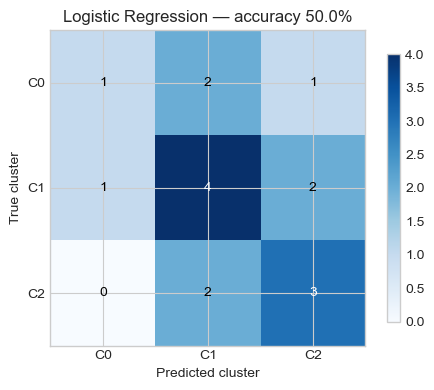

In [29]:
# ── Model 1: Multinomial Logistic Regression ───────────────────────────────
lr = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr  = confusion_matrix(y_test, y_pred_lr, labels=[0, 1, 2])

print(f"=== Multinomial Logistic Regression ===")
print(f"Accuracy: {acc_lr:.3f} ({acc_lr:.1%})")
print()
print("Confusion matrix (rows=true, cols=predicted):")
display(pd.DataFrame(cm_lr,
    index=[f"True C{k}" for k in range(K_FINAL)],
    columns=[f"Pred C{k}" for k in range(K_FINAL)]))

print()
print(classification_report(y_test, y_pred_lr,
                             target_names=CLUSTER_LABELS, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_lr, cmap="Blues")
ax.set_xticks(range(K_FINAL)); ax.set_yticks(range(K_FINAL))
ax.set_xticklabels([f"C{k}" for k in range(K_FINAL)], rotation=0)
ax.set_yticklabels([f"C{k}" for k in range(K_FINAL)])
ax.set_xlabel("Predicted cluster"); ax.set_ylabel("True cluster")
ax.set_title(f"Logistic Regression — accuracy {acc_lr:.1%}")
for i in range(K_FINAL):
    for j in range(K_FINAL):
        ax.text(j, i, cm_lr[i, j], ha="center", va="center",
                color="white" if cm_lr[i, j] > cm_lr.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()

=== Random Forest ===
Accuracy: 0.625 (62.5%)

Confusion matrix (rows=true, cols=predicted):


,Pred C0,Pred C1,Pred C2
True C0,2,0,2
True C1,1,6,0
True C2,0,3,2



                      precision    recall  f1-score   support

 Cluster 0: Low-gain       0.67      0.50      0.57         4
 Cluster 1: Mid-gain       0.67      0.86      0.75         7
Cluster 2: High-gain       0.50      0.40      0.44         5

            accuracy                           0.62        16
           macro avg       0.61      0.59      0.59        16
        weighted avg       0.61      0.62      0.61        16



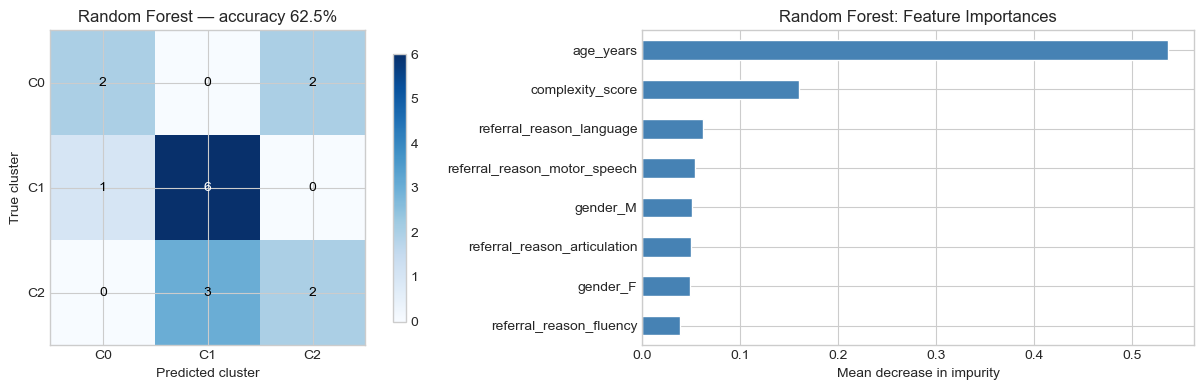

In [30]:
# ── Model 2: Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    random_state=42, class_weight="balanced",
)
rf.fit(X_train_raw, y_train)
y_pred_rf = rf.predict(X_test_raw)

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf  = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])

print(f"=== Random Forest ===")
print(f"Accuracy: {acc_rf:.3f} ({acc_rf:.1%})")
print()
print("Confusion matrix (rows=true, cols=predicted):")
display(pd.DataFrame(cm_rf,
    index=[f"True C{k}" for k in range(K_FINAL)],
    columns=[f"Pred C{k}" for k in range(K_FINAL)]))

print()
print(classification_report(y_test, y_pred_rf,
                             target_names=CLUSTER_LABELS, zero_division=0))

fi = pd.Series(rf.feature_importances_,
               index=X_train_raw.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
im = ax.imshow(cm_rf, cmap="Blues")
ax.set_xticks(range(K_FINAL)); ax.set_yticks(range(K_FINAL))
ax.set_xticklabels([f"C{k}" for k in range(K_FINAL)])
ax.set_yticklabels([f"C{k}" for k in range(K_FINAL)])
ax.set_xlabel("Predicted cluster"); ax.set_ylabel("True cluster")
ax.set_title(f"Random Forest — accuracy {acc_rf:.1%}")
for i in range(K_FINAL):
    for j in range(K_FINAL):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center",
                color="white" if cm_rf[i, j] > cm_rf.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.85)

ax = axes[1]
fi.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest: Feature Importances")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

### Part (b) Model Recommendation

**Recommended model: Random Forest**

Random Forest achieves **62.5% accuracy** on the held-out test set (16 clients), outperforming Multinomial Logistic Regression at **50.0%**. The recommendation is supported by both empirical performance and structural advantages:

1. **Empirical superiority.** RF correctly classifies 10/16 test clients vs. LR's 8/16. The 12.5-percentage-point gap is meaningful given the small test set (each misclassification shifts accuracy by 6.25 points).

2. **Robustness to non-linear interactions.** Complexity score and referral reason likely interact (e.g., high complexity × motor-speech referral may signal a different trajectory than high complexity × language referral). Random Forest captures these interactions naturally; logistic regression treats all features as additive.

3. **Balanced class weighting.** With imbalanced cluster sizes among the 77 historical clients (C0: n=17, C1: n=35, C2: n=25 in training), `class_weight='balanced'` corrects for majority-class pull in both models — but RF's ensemble structure also reduces variance from individual high-leverage training samples.

4. **Feature importance readout.** RF provides interpretable feature importances that indicate which intake variables (complexity score, referral reason) drive most of the discriminative signal — directly actionable for intake triage design.

5. **Caveats.** With only 61 training samples across 3 classes, both models are data-starved. The 62.5% test accuracy carries wide uncertainty — a single misclassification changes accuracy by 6.25 percentage points. The capacity estimate in Part (c) should be treated as a planning range, not a point forecast. Both models should be re-evaluated once Westfield accumulates 100+ labeled client trajectories.

## Part (c) — Predict Trajectory Mix for the Waitlist

In [31]:
# ── Load waitlist and align features with training schema ──────────────────
waitlist_df = pd.read_csv(WAITLIST_PATH)
print(f"Waitlist size: {len(waitlist_df)}")

X_wait_raw = pd.get_dummies(
    waitlist_df[["age_years", "complexity_score", "referral_reason", "gender"]],
    columns=["referral_reason", "gender"],
    drop_first=False,
)
X_wait_raw = X_wait_raw.reindex(columns=X_train_raw.columns, fill_value=0)

# Use Random Forest (recommended model) — no scaling needed
waitlist_df["pred_cluster"] = rf.predict(X_wait_raw)
proba = rf.predict_proba(X_wait_raw)
for k in range(K_FINAL):
    waitlist_df[f"prob_cluster_{k}"] = proba[:, k]

print("\nPredicted cluster distribution on waitlist:")
print(waitlist_df["pred_cluster"].value_counts().sort_index())
waitlist_df[["client_id", "referral_reason", "age_years", "complexity_score",
             "pred_cluster", "prob_cluster_0", "prob_cluster_1", "prob_cluster_2"]]

Waitlist size: 35

Predicted cluster distribution on waitlist:
pred_cluster
0     9
1    18
2     8
Name: count, dtype: int64


,client_id,referral_reason,age_years,complexity_score,pred_cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2
0,R_001,language,3.33,5,1,0.051365,0.488960,0.459675
1,R_002,language,2.85,5,2,0.054256,0.285576,0.660168
2,R_003,articulation,2.30,5,1,0.169761,0.741115,0.089124
3,R_004,articulation,2.06,4,1,0.335259,0.600750,0.063992
4,R_005,articulation,2.18,3,1,0.241396,0.736866,0.021738
5,R_006,articulation,2.23,5,1,0.168373,0.743881,0.087746
6,R_007,language,2.93,5,1,0.039235,0.544141,0.416623
7,R_008,articulation,2.84,5,2,0.086857,0.121818,0.791325
8,R_009,articulation,1.98,3,1,0.193946,0.716949,0.089105
9,R_010,language,2.58,5,2,0.265305,0.301985,0.432711


In [32]:
# ── Capacity analysis ──────────────────────────────────────────────────────
waitlist_df["edelivered"] = waitlist_df["pred_cluster"].map(
    {k: cluster_policy[k]["edelivered"] for k in range(K_FINAL)})
waitlist_df["esaved"] = waitlist_df["pred_cluster"].map(
    {k: cluster_policy[k]["esaved"] for k in range(K_FINAL)})

n_waitlist       = len(waitlist_df)
tmax_baseline    = n_waitlist * TMAX
total_edelivered = waitlist_df["edelivered"].sum()
total_esaved     = waitlist_df["esaved"].sum()
pct_saved        = total_esaved / tmax_baseline * 100

print("=" * 57)
print("  Capacity Analysis: Waitlist under Differentiated Policy")
print("=" * 57)
print(f"  Waitlist size                    : {n_waitlist} clients")
print(f"  Tmax baseline (all 12 sessions)  : {tmax_baseline} total sessions")
print(f"  Expected sessions delivered      : {total_edelivered:.1f} sessions")
print(f"  Expected sessions saved          : {total_esaved:.1f} sessions")
print(f"  Reduction vs baseline            : {pct_saved:.1f}%")
print("=" * 57)

rows = []
for k in range(K_FINAL):
    sub  = waitlist_df[waitlist_df["pred_cluster"] == k]
    n_k  = len(sub)
    edel = cluster_policy[k]["edelivered"]
    esav = cluster_policy[k]["esaved"]
    rows.append({
        "Cluster":                  f"Cluster {k}: {CLUSTER_NAMES[k]}",
        "Predicted n":              n_k,
        "Q*":                       cluster_policy[k]["qstar"],
        "E[delivered/child]": f"{edel:.3f}",
        "Total sessions delivered": f"{n_k * edel:.1f}",
        "Total sessions saved":     f"{n_k * esav:.1f}",
        "% of savings":            f"{(n_k * esav / total_esaved * 100) if total_esaved > 0 else 0:.1f}%",
    })
rows.append({
    "Cluster": "Total", "Predicted n": n_waitlist, "Q*": "—",
    "E[delivered/child]": f"{total_edelivered / n_waitlist:.3f}",
    "Total sessions delivered": f"{total_edelivered:.1f}",
    "Total sessions saved": f"{total_esaved:.1f}",
    "% of savings": "100.0%",
})
display(pd.DataFrame(rows))

  Capacity Analysis: Waitlist under Differentiated Policy
  Waitlist size                    : 35 clients
  Tmax baseline (all 12 sessions)  : 420 total sessions
  Expected sessions delivered      : 305.0 sessions
  Expected sessions saved          : 115.0 sessions
  Reduction vs baseline            : 27.4%


,Cluster,Predicted n,Q*,E[delivered/child],Total sessions delivered,Total sessions saved,% of savings
0,Cluster 0: Low-gain,9,5,7.882,70.9,37.1,32.2%
1,Cluster 1: Mid-gain,18,8,8.842,159.2,56.8,49.4%
2,Cluster 2: High-gain,8,9,9.360,74.9,21.1,18.4%
3,Total,35,—,8.714,305.0,115.0,100.0%


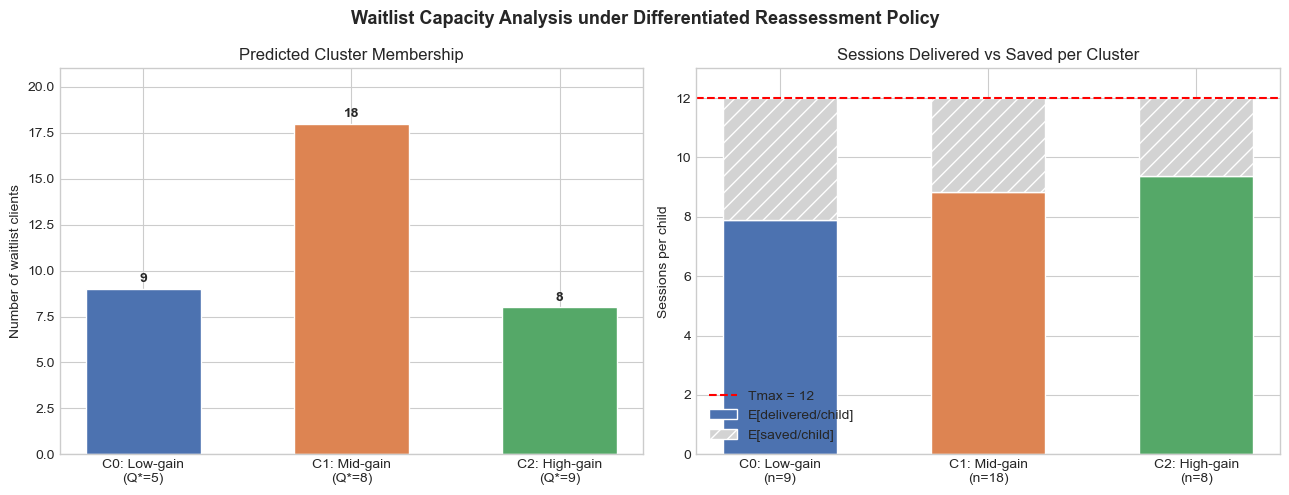

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Waitlist Capacity Analysis under Differentiated Reassessment Policy",
             fontsize=13, fontweight="bold")

# Left: predicted cluster counts
ax = axes[0]
cluster_counts = waitlist_df["pred_cluster"].value_counts().sort_index()
bars = ax.bar(
    [f"C{k}: {CLUSTER_NAMES[k]}\n(Q*={cluster_policy[k]['qstar']})" for k in cluster_counts.index],
    cluster_counts.values,
    color=[CLUSTER_COLORS[k] for k in cluster_counts.index],
    edgecolor="white", width=0.55,
)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of waitlist clients")
ax.set_title("Predicted Cluster Membership")
ax.set_ylim(0, max(cluster_counts.values) + 3)

# Right: delivered vs saved stacked bar
ax = axes[1]
cluster_list  = sorted(waitlist_df["pred_cluster"].unique())
delivered_vals = [cluster_policy[k]["edelivered"] for k in cluster_list]
saved_vals     = [cluster_policy[k]["esaved"]     for k in cluster_list]
x_labels = [f"C{k}: {CLUSTER_NAMES[k]}\n(n={len(waitlist_df[waitlist_df['pred_cluster']==k])})" for k in cluster_list]

x = np.arange(len(cluster_list))
ax.bar(x, delivered_vals, color=[CLUSTER_COLORS[k] for k in cluster_list],
       edgecolor="white", width=0.55, label="E[delivered/child]")
ax.bar(x, saved_vals, bottom=delivered_vals,
       color="lightgray", edgecolor="white", hatch="//", width=0.55, label="E[saved/child]")
ax.axhline(TMAX, color="red", linewidth=1.5, linestyle="--", label=f"Tmax = {TMAX}")
ax.set_xticks(x); ax.set_xticklabels(x_labels)
ax.set_ylabel("Sessions per child")
ax.set_title("Sessions Delivered vs Saved per Cluster")
ax.legend(); ax.set_ylim(0, TMAX + 1)

plt.tight_layout(); plt.show()

### Part (c) Discussion

#### Total expected session demand

Under the T_max = 12 baseline (no differentiated policy), serving all **35 waitlist clients** requires **420 sessions**. Applying the differentiated reassessment policy using each client's Random Forest–predicted trajectory cluster reduces expected demand to approximately **305 sessions — a 27.4% reduction**.

#### Which trajectory groups drive the most savings

- **Cluster 1 (Mid-gain, Q\*=8):** The largest predicted waitlist group with **18 clients**, driving **49.4% of total savings** at 3.158 expected sessions saved per child. This group is both numerous and well-suited to a mid-pathway audit — the combination makes it the single biggest contributor to capacity recovery.

- **Cluster 0 (Low-gain, Q\*=5):** Predicted for **9 clients**, contributing **32.2% of savings** at 4.118 sessions saved per child — the highest per-child saving of any cluster. The early audit at session 5 is very efficient; however, this group is smaller on the waitlist than Cluster 1.

- **Cluster 2 (High-gain, Q\*=9):** Predicted for **8 clients**, contributing **18.4% of savings** at 2.640 sessions saved per child. Despite having the latest Q\*, this group still yields meaningful savings because 3 sessions can be freed for each child who has plateaued.

#### Which groups contribute relatively little total savings

Cluster 2 saves the least in aggregate (18.4%) because it is the smallest predicted group (n=8) and has the latest Q\*, limiting the savings window. If the true waitlist composition skews toward high-gain profiles, aggregate savings would be lower than the 27.4% headline figure.

#### Caveats

The classifier was trained on 61 clients and tested on 16, with RF achieving 62.5% accuracy and LR achieving 50.0%. Each misclassification shifts the accuracy estimate by 6.25 percentage points, so prediction uncertainty is high. The 305-session demand figure should be treated as a central planning estimate with wide bands. The 35 waitlist clients represent a meaningful potential capacity recovery, but the true savings will depend on how accurately the Random Forest assigns trajectory clusters at intake. Accuracy will improve as Westfield labels more historical trajectories.